<a href="https://colab.research.google.com/github/zizimostafa/MNIST-DL-Project/blob/main/Final_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# Load Dataset

In [40]:
transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))

])

train_dataset = torchvision.datasets.MNIST(

    root="./data",
    train=True,
    download=True,
    transform=transform

)

test_dataset = torchvision.datasets.MNIST(

    root="./data",
    train=False,
    download=True,
    transform=transform

)

train_loader = DataLoader(

    train_dataset,
    batch_size=64,
    shuffle=True

)

test_loader = DataLoader(

    test_dataset,
    batch_size=64,
    shuffle=False

)

# CNN Model

In [41]:
class SimpleCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 128),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128, 10)

        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

# Training + Testing Function

In [42]:
def train_and_evaluate(optimizer_name):

    model = SimpleCNN().to(device)

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=0.001
        )

    elif optimizer_name == "SGD":

        optimizer = optim.SGD(
            model.parameters(),
            lr=0.01
        )

    train_losses = []

    train_accuracies = []

    epochs = 5

    # ================= TRAINING =================

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        correct = 0

        total = 0

        for images, labels in train_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()

            total += labels.size(0)

        accuracy = 100 * correct / total

        avg_loss = total_loss / len(train_loader)

        train_losses.append(avg_loss)

        train_accuracies.append(accuracy)

        print(
            f"{optimizer_name} Epoch {epoch+1} | "
            f"Loss: {avg_loss:.4f} | "
            f"Acc: {accuracy:.2f}%"
        )

    # ================= TESTING =================

    model.eval()

    correct = 0

    total = 0

    test_loss = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()

            total += labels.size(0)

    test_accuracy = 100 * correct / total

    avg_test_loss = test_loss / len(test_loader)

    print(f"\n{optimizer_name} TEST ACCURACY: {test_accuracy:.2f}%")

    print(f"{optimizer_name} TEST LOSS: {avg_test_loss:.4f}")

    return train_losses, train_accuracies, test_accuracy, avg_test_loss

In [43]:
adam_losses, adam_accs, adam_test_acc, adam_test_loss = train_and_evaluate("Adam")
sgd_losses, sgd_accs, sgd_test_acc, sgd_test_loss = train_and_evaluate("SGD")

Adam Epoch 1 | Loss: 0.2937 | Acc: 90.95%
Adam Epoch 2 | Loss: 0.1088 | Acc: 96.81%
Adam Epoch 3 | Loss: 0.0822 | Acc: 97.59%
Adam Epoch 4 | Loss: 0.0651 | Acc: 98.09%
Adam Epoch 5 | Loss: 0.0564 | Acc: 98.28%

Adam TEST ACCURACY: 99.12%
Adam TEST LOSS: 0.0276
SGD Epoch 1 | Loss: 1.0570 | Acc: 68.05%
SGD Epoch 2 | Loss: 0.3034 | Acc: 90.95%
SGD Epoch 3 | Loss: 0.1956 | Acc: 94.27%
SGD Epoch 4 | Loss: 0.1537 | Acc: 95.48%
SGD Epoch 5 | Loss: 0.1289 | Acc: 96.20%

SGD TEST ACCURACY: 97.71%
SGD TEST LOSS: 0.0699


# LOSS GRAPH

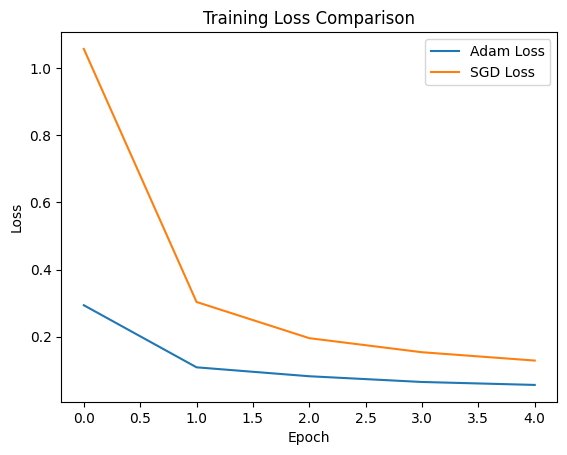

In [44]:
plt.plot(adam_losses, label="Adam Loss")

plt.plot(sgd_losses, label="SGD Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss Comparison")

plt.legend()

plt.show()

# ACCURACY GRAPH

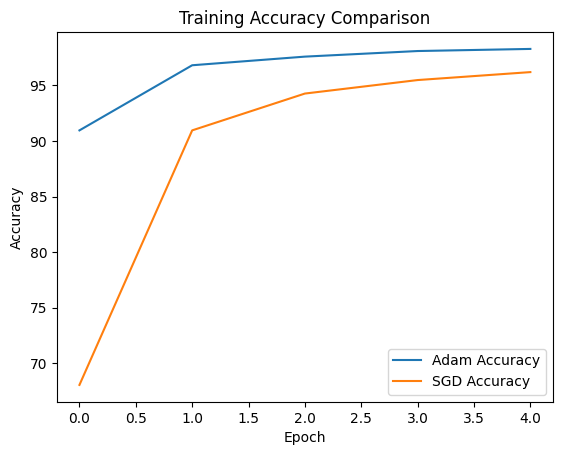

In [45]:
plt.plot(adam_accs, label="Adam Accuracy")

plt.plot(sgd_accs, label="SGD Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy Comparison")

plt.legend()

plt.show()


# Comparison Table

In [48]:
print("===== FINAL COMPARISON =====")
print(f"Adam Accuracy : {adam_test_acc:.2f}%")
print(f"Adam Loss     : {adam_test_loss:.4f}")



print(f"SGD Accuracy  : {sgd_test_acc:.2f}%")
print(f"SGD Loss      : {sgd_test_loss:.4f}")

===== FINAL COMPARISON =====
Adam Accuracy : 99.12%
Adam Loss     : 0.0276
SGD Accuracy  : 97.71%
SGD Loss      : 0.0699
